# Example notebook

In [26]:
%matplotlib inline
from skimage import transform
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from floortrans.models import get_model
from floortrans.loaders import FloorplanSVG, DictToTensor, Compose, RotateNTurns
from floortrans.plotting import segmentation_plot, polygons_to_image, draw_junction_from_dict, discrete_cmap
from floortrans.post_prosessing import split_prediction, get_polygons, split_validation
from mpl_toolkits.axes_grid1 import AxesGrid
import glob
from PIL import Image

rot = RotateNTurns()
room_classes = ["Background", "Outdoor", "Wall", "Kitchen", "Living Room" ,"Bed Room", "Bath", "Entry", "Railing", "Storage", "Garage", "Undefined"]
icon_classes = ["No Icon", "Window", "Door", "Closet", "Electrical Applience" ,"Toilet", "Sink", "Sauna Bench", "Fire Place", "Bathtub", "Chimney"]

# Load your floorplan images directly
data_folder = 'data/cubicasa5k/'
image_files = glob.glob(data_folder + '*.png')
print(f"✅ Found {len(image_files)} floorplan images")
for i, img_path in enumerate(image_files, 1):
    print(f"  {i}. {img_path}")

# Setup Model
model = get_model('hg_furukawa_original', 51)

n_classes = 44
split = [21, 12, 11]
model.conv4_ = torch.nn.Conv2d(256, n_classes, bias=True, kernel_size=1)
model.upsample = torch.nn.ConvTranspose2d(n_classes, n_classes, kernel_size=4, stride=4)
checkpoint = torch.load('model_best_val_loss_var.pkl', map_location='cuda' if torch.cuda.is_available() else 'cpu')

model.load_state_dict(checkpoint['model_state'])
model.eval()

if torch.cuda.is_available():
    model.cuda()
    print("✅ Model loaded successfully on GPU!")
else:
    print("✅ Model loaded successfully on CPU!")

✅ Found 3 floorplan images
  1. data/cubicasa5k\floorplan1.png
  2. data/cubicasa5k\floorplan2.png
  3. data/cubicasa5k\floorplan3.png
✅ Model loaded successfully on GPU!


## Testing Model Loading (Without Dataset)

Let's first test if the model loads successfully without requiring the full CubiCasa5k dataset.

## Run Inference on Your Floorplan Images

Let's process one of your uploaded floorplan images.

Processing: data/cubicasa5k\floorplan1.png
Original size: (1414, 800)
✅ Image preprocessed: torch.Size([1, 3, 256, 256])


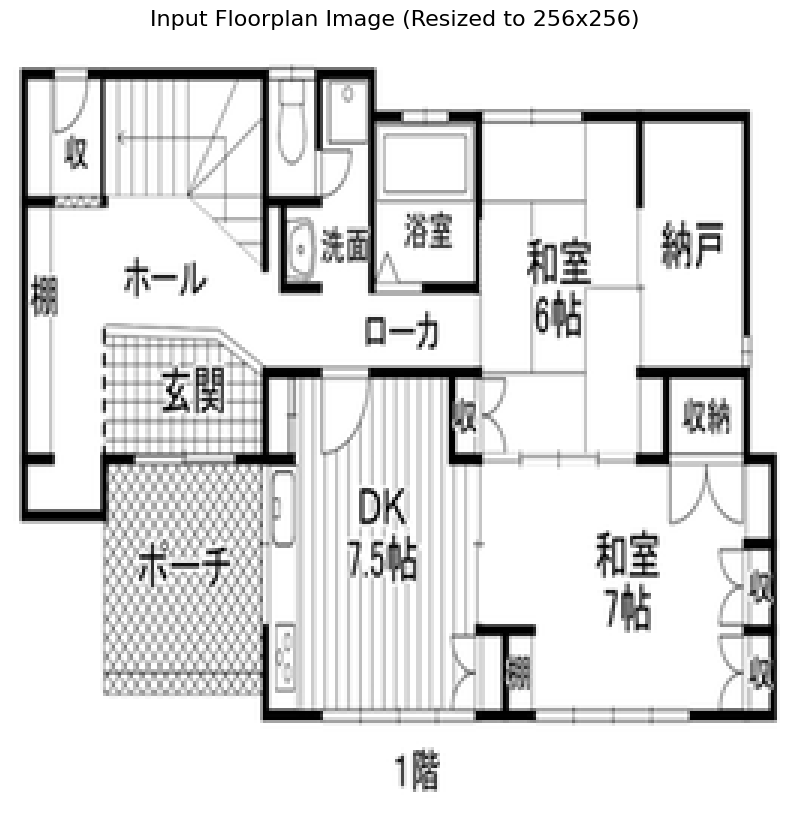

In [41]:
# Select which image to process (0 to 4 for your 5 images)
image_index = 0 # Change this to try different images
selected_image_path = image_files[image_index]

print(f"Processing: {selected_image_path}")

# Load and preprocess the image
from PIL import Image
import torchvision.transforms as transforms

# Load image
pil_image = Image.open(selected_image_path).convert('RGB')
original_size = pil_image.size
print(f"Original size: {original_size}")

# Resize to model input size (256x256 is standard)
target_size = 256
pil_image_resized = pil_image.resize((target_size, target_size), Image.LANCZOS)

# Convert to tensor and normalize
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

image_tensor = transform(pil_image_resized).unsqueeze(0)  # Add batch dimension

# Move to GPU if available
if torch.cuda.is_available():
    image_tensor = image_tensor.cuda()

print(f"✅ Image preprocessed: {image_tensor.shape}")

# Display the input image
np_img = np.array(pil_image_resized) / 255.0
plt.figure(figsize=(10,10))
plt.title(f'Input Floorplan Image (Resized to {target_size}x{target_size})', fontsize=16)
plt.axis('off')
plt.imshow(np_img)
plt.show()

## Measure Inference Time

We'll use this cell to measure how long the inference takes.

Running inference...
✅ Inference complete!
⏱️ Inference time: 0.404 seconds
✅ Inference complete!
⏱️ Inference time: 0.404 seconds


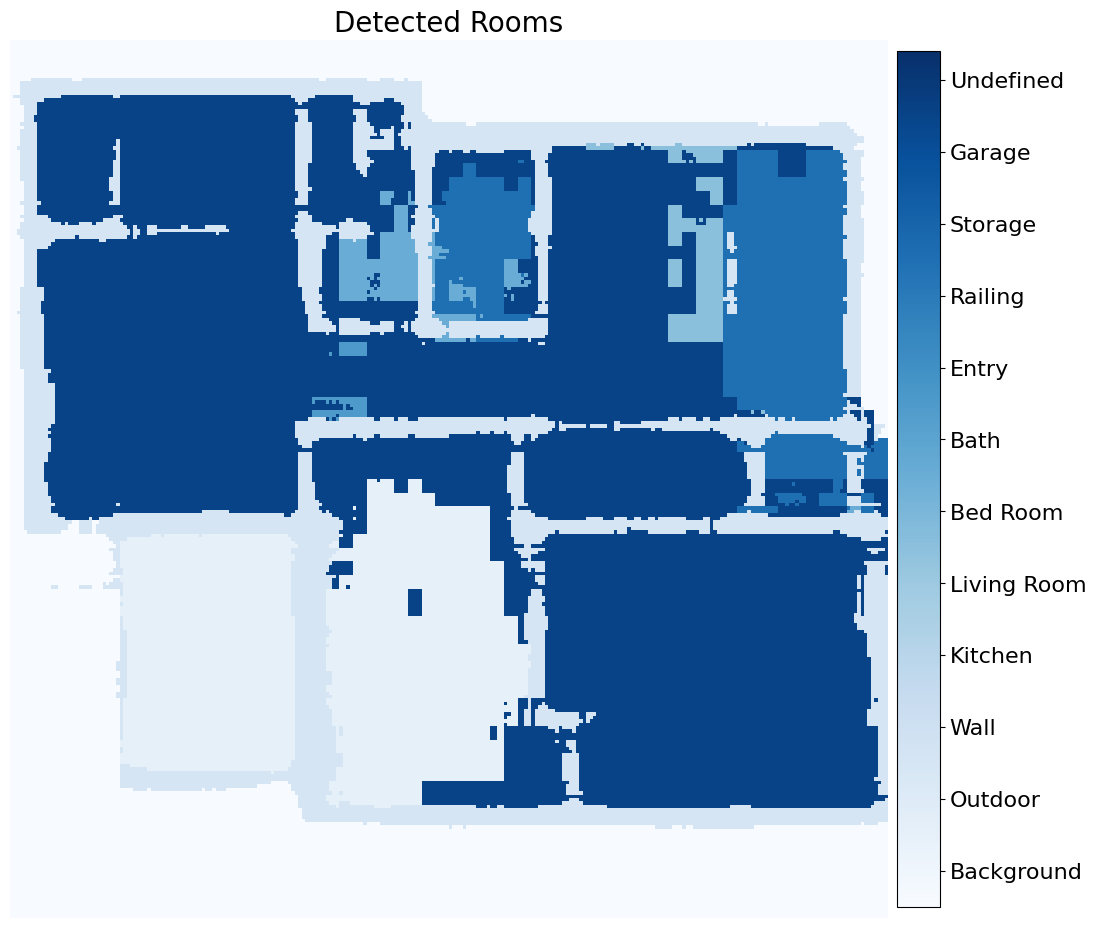

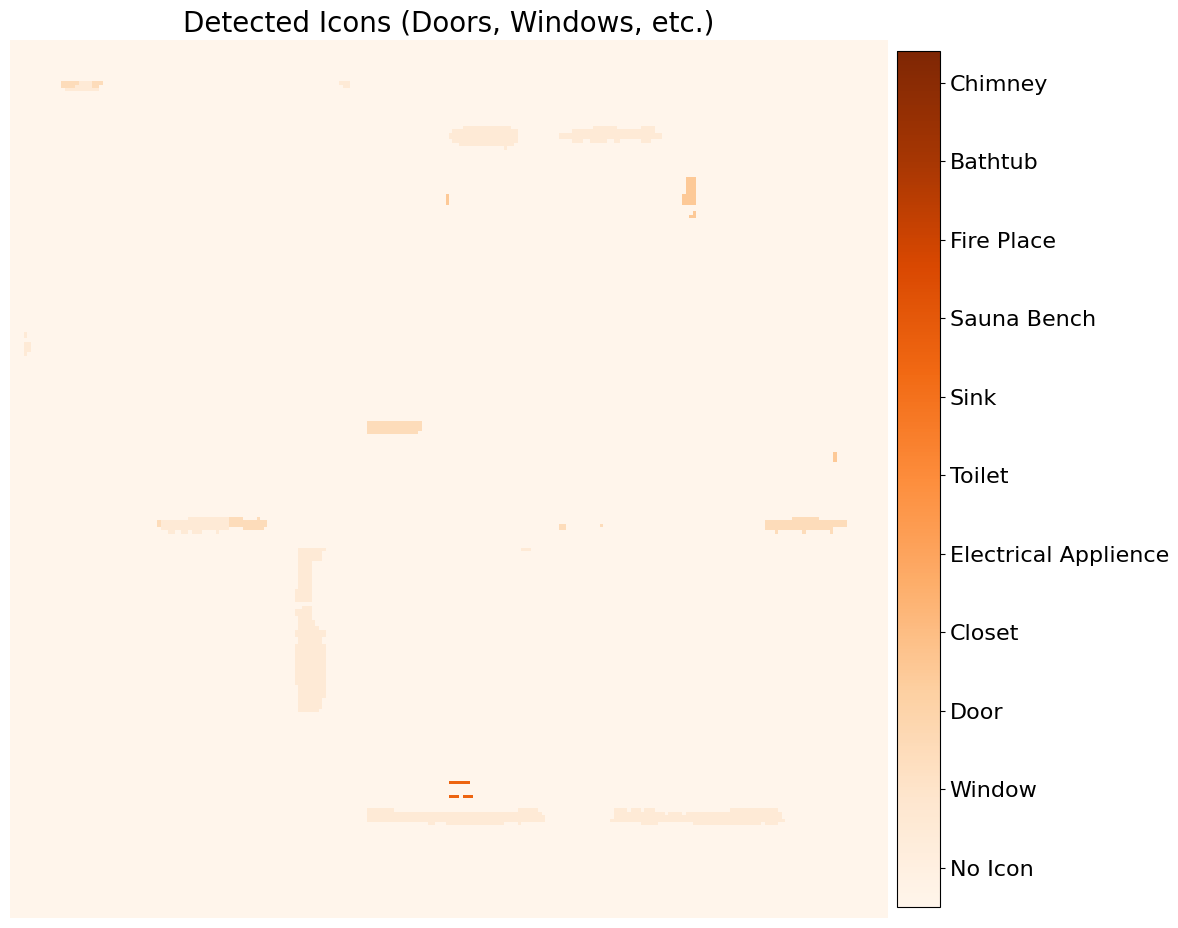

In [42]:
import time

# Run model inference with timing
print("Running inference...")
start_time = time.time()

with torch.no_grad():
    height = target_size
    width = target_size
    img_size = (height, width)
    
    # Test-time augmentation with rotations
    rotations = [(0, 0), (1, -1), (2, 2), (-1, 1)]
    pred_count = len(rotations)
    prediction = torch.zeros([pred_count, n_classes, height, width])
    
    if torch.cuda.is_available():
        prediction = prediction.cuda()
    
    for i, r in enumerate(rotations):
        forward, back = r
        # Rotate the image
        rot_image = rot(image_tensor, 'tensor', forward)
        # Get prediction
        pred = model(rot_image)
        # Rotate prediction back
        pred = rot(pred, 'tensor', back)
        # Fix heatmaps
        pred = rot(pred, 'points', back)
        # Ensure correct size
        pred = F.interpolate(pred, size=(height, width), mode='bilinear', align_corners=True)
        # Add to predictions
        prediction[i] = pred[0]
    
    # Average predictions from all rotations
    prediction = torch.mean(prediction, 0, True)

end_time = time.time()
inference_time = end_time - start_time

print(f"✅ Inference complete!")
print(f"⏱️ Inference time: {inference_time:.3f} seconds")

# Extract room and icon predictions
rooms_pred = F.softmax(prediction[0, 21:21+12], 0).cpu().data.numpy()
rooms_pred = np.argmax(rooms_pred, axis=0)

icons_pred = F.softmax(prediction[0, 21+12:], 0).cpu().data.numpy()
icons_pred = np.argmax(icons_pred, axis=0)

# Visualize room segmentation
n_rooms = 12
plt.figure(figsize=(12,12))
ax = plt.subplot(1, 1, 1)
ax.axis('off')
plt.title('Detected Rooms', fontsize=20)
rseg = ax.imshow(rooms_pred, cmap='Blues', vmin=0, vmax=n_rooms-0.1)
cbar = plt.colorbar(rseg, ticks=np.arange(n_rooms) + 0.5, fraction=0.046, pad=0.01)
cbar.ax.set_yticklabels(room_classes, fontsize=16)
plt.show()

# Visualize icon segmentation
n_icons = 11
plt.figure(figsize=(12,12))
ax = plt.subplot(1, 1, 1)
ax.axis('off')
plt.title('Detected Icons (Doors, Windows, etc.)', fontsize=20)
iseg = ax.imshow(icons_pred, cmap='Oranges', vmin=0, vmax=n_icons-0.1)
cbar = plt.colorbar(iseg, ticks=np.arange(n_icons) + 0.5, fraction=0.046, pad=0.01)
cbar.ax.set_yticklabels(icon_classes, fontsize=16)
plt.show()

In [16]:
# Test: Load model without dataset
import torch
from floortrans.models import get_model

# Setup Model
model = get_model('hg_furukawa_original', 51)

n_classes = 44
split = [21, 12, 11]
model.conv4_ = torch.nn.Conv2d(256, n_classes, bias=True, kernel_size=1)
model.upsample = torch.nn.ConvTranspose2d(n_classes, n_classes, kernel_size=4, stride=4)

# Load pretrained weights
checkpoint = torch.load('model_best_val_loss_var.pkl', map_location='cuda' if torch.cuda.is_available() else 'cpu')
model.load_state_dict(checkpoint['model_state'])
model.eval()

# Move to GPU if available
if torch.cuda.is_available():
    model.cuda()
    print("✅ Model loaded successfully on GPU!")
else:
    print("✅ Model loaded successfully on CPU!")
    
print(f"Model architecture: {type(model).__name__}")

✅ Model loaded successfully on GPU!
Model architecture: hg_furukawa_original


In [17]:
val = next(data_iter)
junctions = val['heatmaps']
folder = val['folder'][0]
image = val['image'].cuda()
label = val['label']
np_img = np.moveaxis(image[0].cpu().data.numpy(), 0, -1) / 2 + 0.5
plt.figure(figsize=(10,10))
plt.title('Source Image', fontsize=20)
plt.axis('off')
plt.imshow(np_img)
plt.show()

NameError: name 'data_iter' is not defined

## The SVG floorplan
If the floorplan includes two floors the other floor might not be visible, but it will be parsed never the less.

In [3]:
from IPython.display import Image
from IPython.core.display import HTML 
Image(url= data_folder+folder+"model.svg", width=800)

## Parsed labels

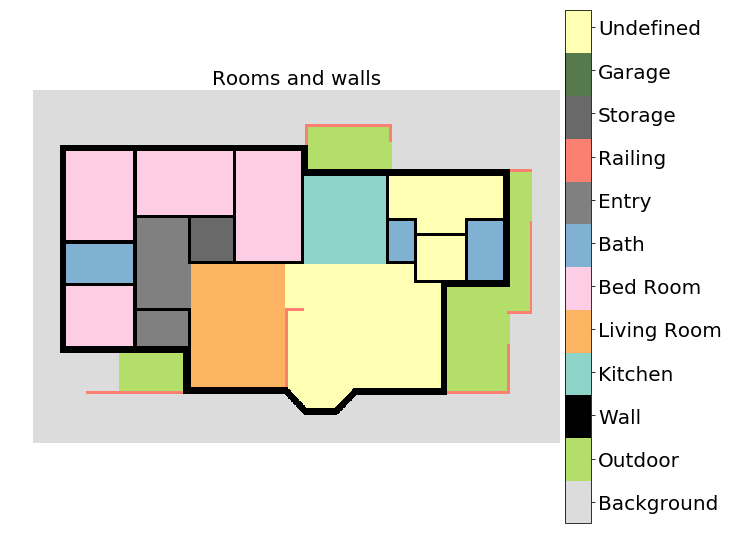

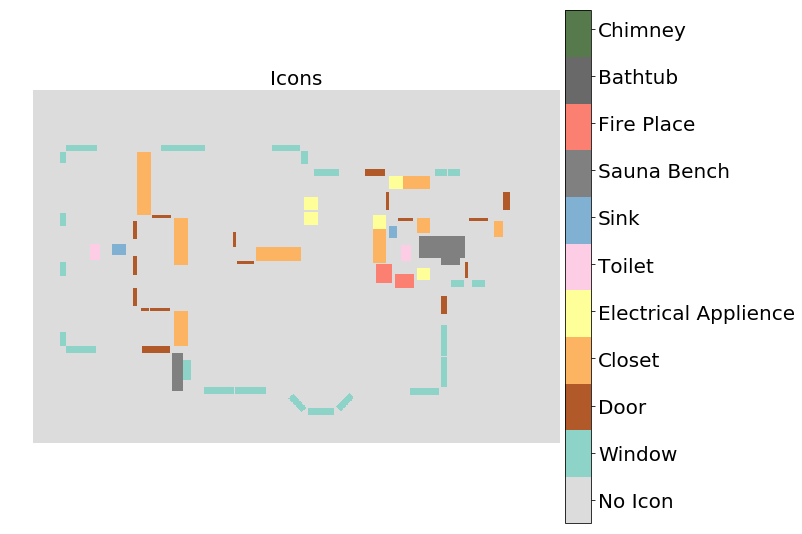

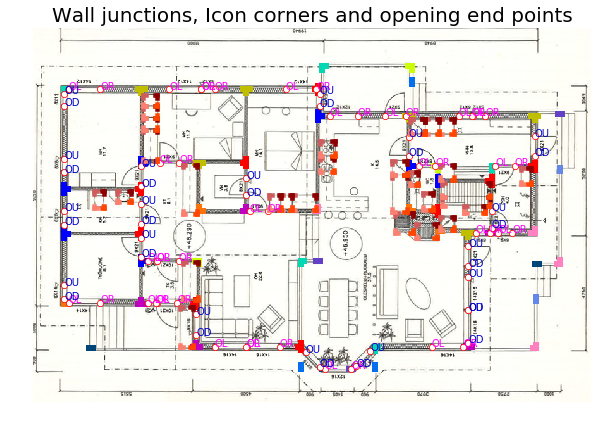

In [4]:
label_np = label.data.numpy()[0]
plt.figure(figsize=(10,10))
ax = plt.subplot(1, 1, 1)
plt.title('Rooms and walls', fontsize=20)
ax.axis('off')
n_rooms = 12
rseg = ax.imshow(label_np[0], cmap='rooms', vmin=0, vmax=n_rooms-0.1)
cbar = plt.colorbar(rseg, ticks=np.arange(n_rooms) + 0.5, fraction=0.046, pad=0.01)
cbar.ax.set_yticklabels(room_classes, fontsize=20)
plt.show()

plt.figure(figsize=(10,10))
ax = plt.subplot(1, 1, 1)
plt.title('Icons', fontsize=20)
ax.axis('off')
n_icons = 11
iseg = ax.imshow(label_np[1], cmap='icons', vmin=0, vmax=n_icons-0.1)
cbar = plt.colorbar(iseg, ticks=np.arange(n_icons) + 0.5, fraction=0.046, pad=0.01)
cbar.ax.set_yticklabels(icon_classes, fontsize=20)
plt.show()

plt.figure(figsize=(10,10))
ax = plt.subplot(1, 1, 1)
plt.title('Wall junctions, Icon corners and opening end points', fontsize=20)
ax.axis('off')
ax.imshow(np_img)
h, w, _ = np_img.shape
draw_junction_from_dict(junctions, w, h, size=0.3, fontsize=10)
plt.show()

## Networks prediction for the segmentation

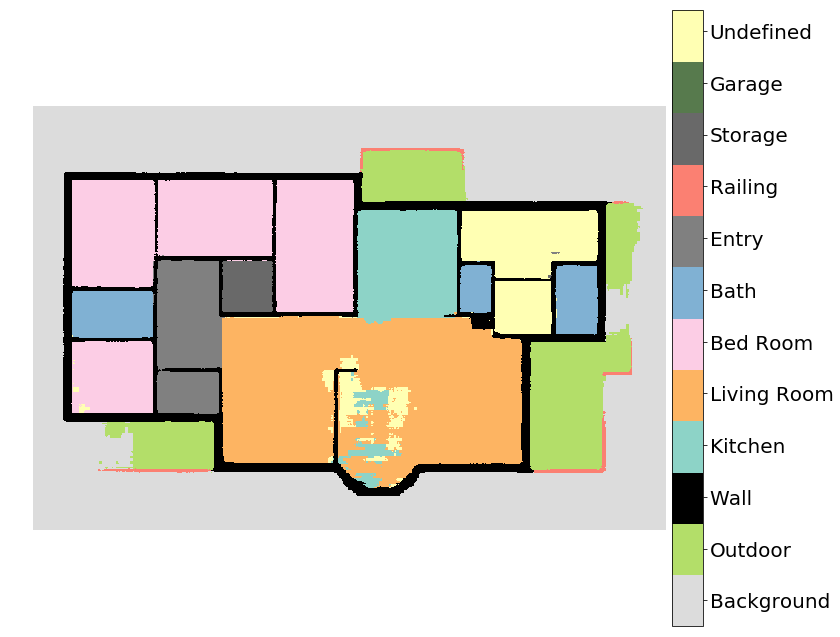

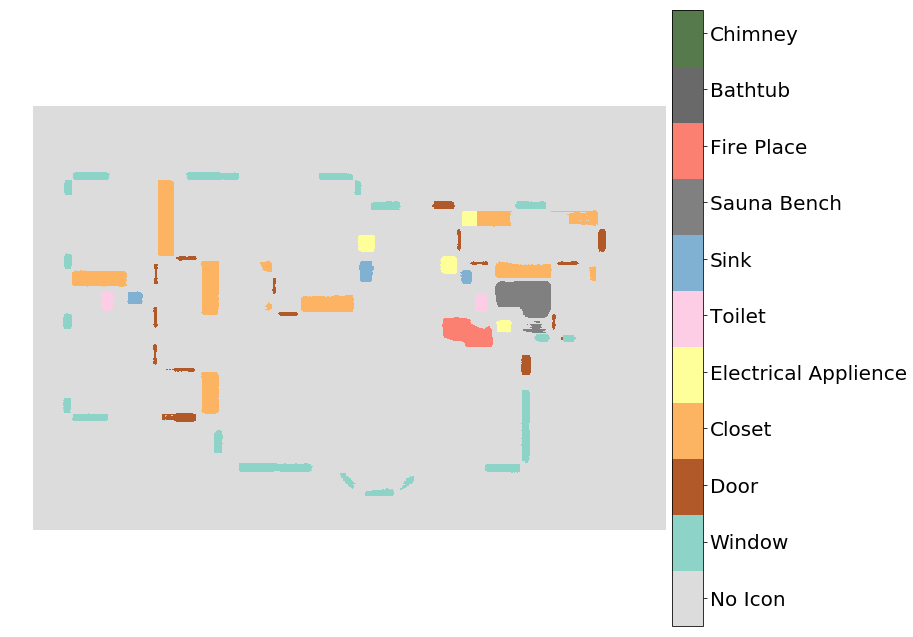

In [5]:
with torch.no_grad():
    height = label_np.shape[1]
    width = label_np.shape[2]
    img_size = (height, width)
    
    rotations = [(0, 0), (1, -1), (2, 2), (-1, 1)]
    pred_count = len(rotations)
    prediction = torch.zeros([pred_count, n_classes, height, width])
    for i, r in enumerate(rotations):
        forward, back = r
        # We rotate first the image
        rot_image = rot(image, 'tensor', forward)
        pred = model(rot_image)
        # We rotate prediction back
        pred = rot(pred, 'tensor', back)
        # We fix heatmaps
        pred = rot(pred, 'points', back)
        # We make sure the size is correct
        pred = F.interpolate(pred, size=(height, width), mode='bilinear', align_corners=True)
        # We add the prediction to output
        prediction[i] = pred[0]

prediction = torch.mean(prediction, 0, True)
rooms_label = label_np[0]
icons_label = label_np[1]

rooms_pred = F.softmax(prediction[0, 21:21+12], 0).cpu().data.numpy()
rooms_pred = np.argmax(rooms_pred, axis=0)

icons_pred = F.softmax(prediction[0, 21+12:], 0).cpu().data.numpy()
icons_pred = np.argmax(icons_pred, axis=0)

plt.figure(figsize=(12,12))
ax = plt.subplot(1, 1, 1)
ax.axis('off')
rseg = ax.imshow(rooms_pred, cmap='rooms', vmin=0, vmax=n_rooms-0.1)
cbar = plt.colorbar(rseg, ticks=np.arange(n_rooms) + 0.5, fraction=0.046, pad=0.01)
cbar.ax.set_yticklabels(room_classes, fontsize=20)
plt.show()

plt.figure(figsize=(12,12))
ax = plt.subplot(1, 1, 1)
ax.axis('off')
iseg = ax.imshow(icons_pred, cmap='icons', vmin=0, vmax=n_icons-0.1)
cbar = plt.colorbar(iseg, ticks=np.arange(n_icons) + 0.5, fraction=0.046, pad=0.01)
cbar.ax.set_yticklabels(icon_classes, fontsize=20)
plt.show()

## Post-processed polygons

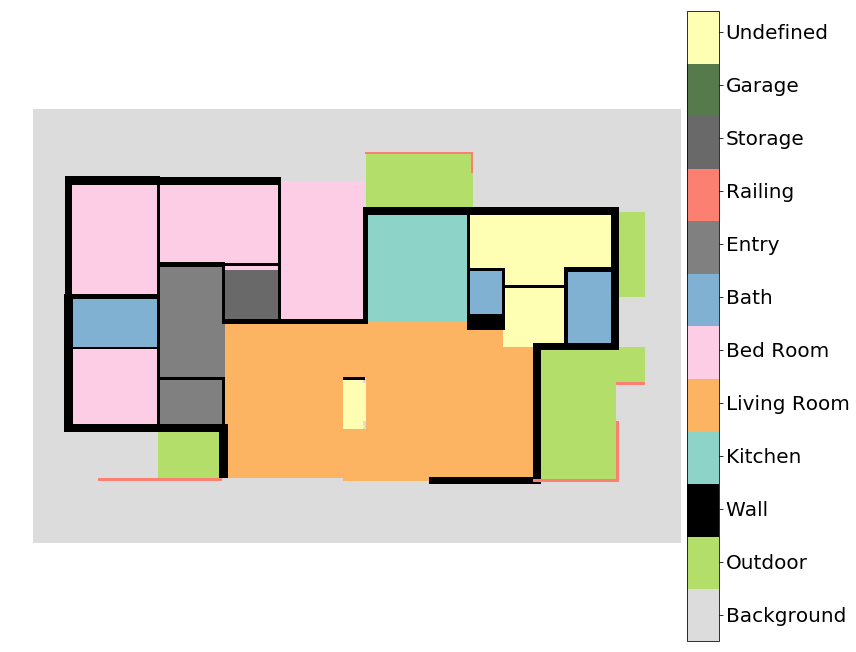

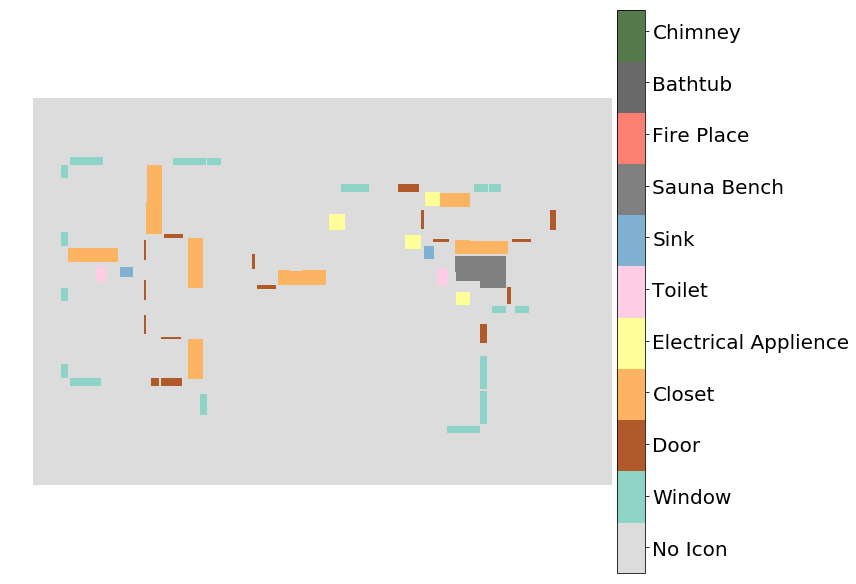

In [6]:

heatmaps, rooms, icons = split_prediction(prediction, img_size, split)
polygons, types, room_polygons, room_types = get_polygons((heatmaps, rooms, icons), 0.2, [1, 2])

pol_room_seg, pol_icon_seg = polygons_to_image(polygons, types, room_polygons, room_types, height, width)
plt.figure(figsize=(12,12))
ax = plt.subplot(1, 1, 1)
ax.axis('off')
rseg = ax.imshow(pol_room_seg, cmap='rooms', vmin=0, vmax=n_rooms-0.1)
cbar = plt.colorbar(rseg, ticks=np.arange(n_rooms) + 0.5, fraction=0.046, pad=0.01)
cbar.ax.set_yticklabels(room_classes, fontsize=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,12))
ax = plt.subplot(1, 1, 1)
ax.axis('off')
iseg = ax.imshow(pol_icon_seg, cmap='icons', vmin=0, vmax=n_icons-0.1)
cbar = plt.colorbar(iseg, ticks=np.arange(n_icons) + 0.5, fraction=0.046, pad=0.01)
cbar.ax.set_yticklabels(icon_classes, fontsize=20)
plt.tight_layout()
plt.show()

## Ground truth and prediction comparisons

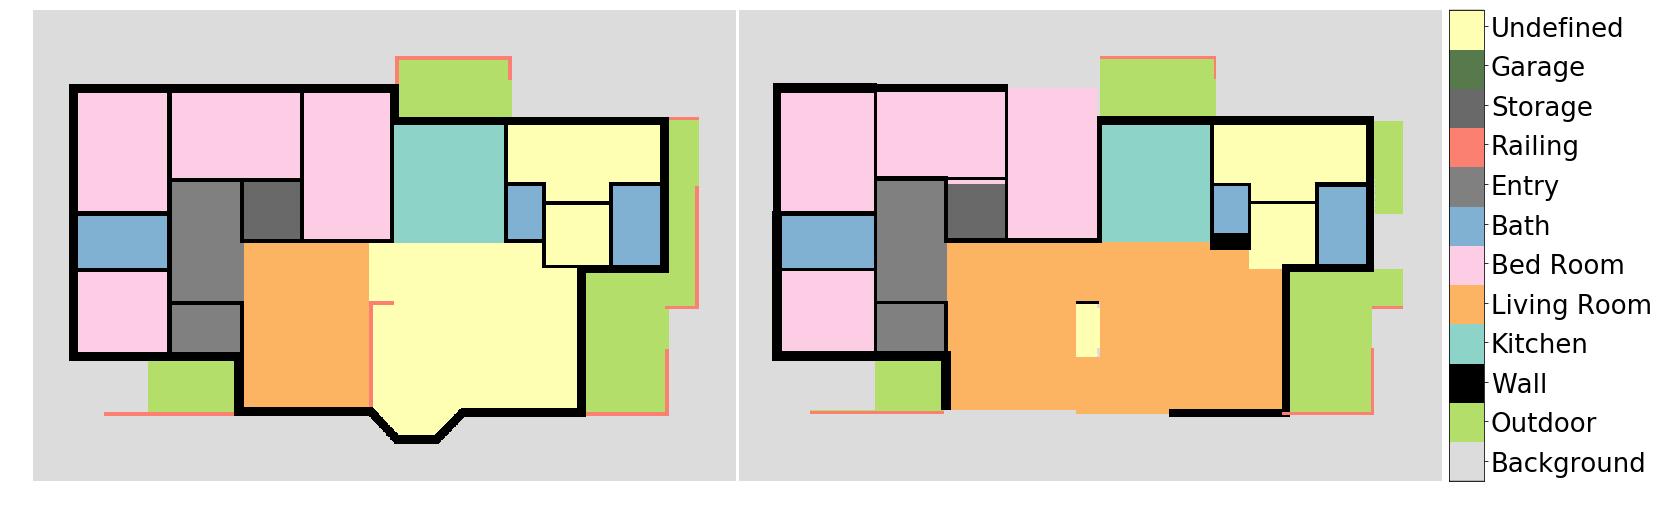

In [7]:
fig = plt.figure(figsize=(26, 12))
grid = AxesGrid(fig, 111,
                nrows_ncols=(1, 2),
                axes_pad=0.05,
                cbar_mode='single',
                cbar_location='right',
                cbar_pad=0.1
                )
images = [label_np[0], pol_room_seg]
for i, ax in enumerate(grid):
    ax.set_axis_off()
    im = ax.imshow(images[i], cmap='rooms', vmin=0, vmax=n_rooms-0.1)
cbar = ax.cax.colorbar(rseg, ticks=np.arange(n_rooms) + 0.5)
cbar.ax.set_yticklabels(room_classes, fontsize=26)
plt.show()

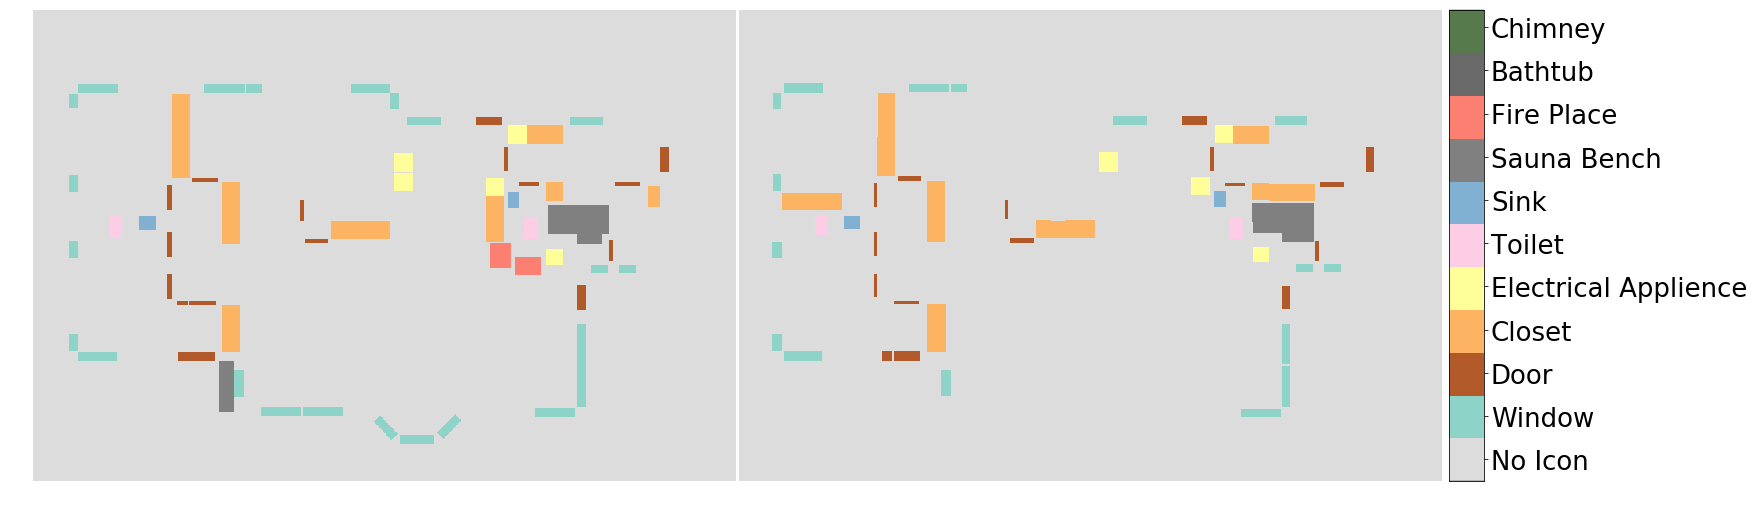

In [8]:
fig = plt.figure(figsize=(26, 12))
grid = AxesGrid(fig, 111,
                nrows_ncols=(1, 2),
                axes_pad=0.05,
                cbar_mode='single',
                cbar_location='right',
                cbar_pad=0.1
                )

images = [label_np[1], pol_icon_seg]
for i, ax in enumerate(grid):
    ax.set_axis_off()
    im = ax.imshow(images[i], cmap='icons', vmin=0, vmax=n_icons-0.1)

cbar = ax.cax.colorbar(iseg, ticks=np.arange(n_icons) + 0.5)
cbar.ax.set_yticklabels(icon_classes, fontsize=26)
plt.show()